#### This notebook will look at all positive labels and compare the embedding trajectory (calculate L2) of a positive labels to its neighbors in (pos, neg), (pos, pos) and randomly sample (neg, neg) pairs at increasing distances to determine how different neighboring labels' trajectories are. 

### Setup

Everything this notebook writes goes to `data/neighbor_trajectory_2019_2024/`. The trajectory itself is the cache `labels_kneighbors.ipynb` built (2019 minus 2017, 64 dims, float16), so run that notebook first if it is missing.

Negatives here are `label_raw == 0`, remained wetland only. `label.npy` folds class 2 (converted to other, not developed) into 0, but those pixels did change, so mixing them in would blur exactly the contrast this notebook is after. They are tracked as their own partner class instead.

In [1]:
import json
import time
import warnings
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from scipy import ndimage

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))

import arrays as array_io
from features import YEARS_2017_2019, emb_cols

ARRAY_DIR = ROOT / "data/arrays_2019_2024"
TRAJ_PATH = ROOT / "data/knn_trajectory_2019_2024/traj_2019_minus_2017.npy"
OUT_DIR = ROOT / "data/neighbor_trajectory_2019_2024"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Chebyshev ring radii in pixels (30 m each), roughly log spaced from 30 m to 10 km.
RINGS = np.array([1, 2, 3, 4, 6, 8, 12, 16, 24, 33, 50, 67, 100, 167, 333])
# Rings up to r = 4 have at most 32 cells and are used whole. Bigger rings get
# 32 cells per anchor, evenly spaced around the ring from a random start.
OFFSETS_PER_RING = 32
N_NEG_ANCHORS = 500_000
N_RANDOM_PAIRS = 1_000_000
N_DIST_BINS = 20
CHUNK = 50_000
SEED = 0

# Partner classes. 1 and 3 together are all positive partners; they are split
# so pairs inside one development patch can be told apart from pairs across patches.
PARTNER_CLASSES = {
    0: "remained wetland",
    1: "converted to developed, other patch",
    2: "converted to other, not developed",
    3: "converted to developed, same patch",
}

In [2]:
arrays, manifest = array_io.load_arrays(
    ARRAY_DIR, optional=("label_raw", "rowcol"), emb_columns=emb_cols(YEARS_2017_2019)
)
label_raw = np.array(arrays["label_raw"])
dist = arrays["dist"]
block_code = arrays["block_code"]
n_rows = len(label_raw)
assert np.array_equal(arrays["label"] == 1, label_raw == 1)

traj_meta = {
    "definition": "A00_2019..A63_2019 minus A00_2017..A63_2017",
    "source_array_dir": str(ARRAY_DIR.relative_to(ROOT)),
    "source_built_utc": manifest["built_utc"],
    "source_git_commit": manifest["git_commit"],
}
with open(TRAJ_PATH.with_suffix(".json")) as fh:
    if json.load(fh) != traj_meta:
        raise ValueError(f"{TRAJ_PATH} was built from a different array artifact, rebuild it in labels_kneighbors.ipynb")
traj = np.load(TRAJ_PATH)
assert traj.shape == (n_rows, 64)

print(f"arrays built {manifest['built_utc']} at commit {manifest['git_commit'][:10]}")
class_counts = np.bincount(label_raw, minlength=3)
for c, name in enumerate(["remained wetland", "converted to developed", "converted to other, not developed"]):
    print(f"{c}  {name:<36} {class_counts[c]:>12,}")

arrays built 2026-09-04T20:02:03Z at commit 88e677b78d


0  remained wetland                       58,878,170
1  converted to developed                    165,908
2  converted to other, not developed         223,253


### Spatial lookup

`rowcol` is one global 30 m grid with a unique (row, col) per pixel, so a neighbor is just an offset in key space and a `searchsorted`. Only 2019 wetland pixels are in the arrays, so plenty of offsets land on nothing (uplands, water, things already developed). Those come back as -1.

In [3]:
R_MAX = int(RINGS.max())
rc = np.asarray(arrays["rowcol"]).astype(np.int64)
# Shift by R_MAX and pad the row width by 2 * R_MAX so that col + dc can never
# run off one row and wrap into the next, which would hand back a real pixel
# on the far side of the state.
ROW0, COL0 = rc.min(axis=0) - R_MAX
W = int(rc[:, 1].max() - COL0) + R_MAX + 1
key = (rc[:, 0] - ROW0) * W + (rc[:, 1] - COL0)
key_order = np.argsort(key, kind="stable").astype(np.int32)
key_sorted = key[key_order]
assert np.all(np.diff(key_sorted) > 0), "rowcol has duplicate pixels"


def lookup(q):
    """Row index for each key in q, or -1 where no pixel sits there."""
    i = np.searchsorted(key_sorted, q)
    np.minimum(i, len(key_sorted) - 1, out=i)
    hit = key_sorted[i] == q
    return np.where(hit, key_order[i], -1)


# Every pixel should find itself.
check = np.random.default_rng(SEED).choice(n_rows, 1_000_000, replace=False)
assert np.array_equal(lookup(key[check]), check)
del check

### Positive patches

Positives come in clumps, and at r = 1 a positive's positive neighbor is almost always the same development footprint. Patches are 8 connected components of positive pixels on the grid. Two positives separated by a pixel that is not in the arrays (a road already developed in 2019, say) end up in different patches, which is the right call here.

In [4]:
pos_rows = np.flatnonzero(label_raw == 1)
pos_rc = rc[pos_rows] - rc[pos_rows].min(axis=0)
grid = np.zeros(pos_rc.max(axis=0) + 1, dtype=bool)
grid[pos_rc[:, 0], pos_rc[:, 1]] = True
patch_grid, n_patches = ndimage.label(grid, structure=np.ones((3, 3), dtype=bool))
patch = np.zeros(n_rows, dtype=np.int32)
patch[pos_rows] = patch_grid[pos_rc[:, 0], pos_rc[:, 1]]
del grid, patch_grid, pos_rc

patch_size = np.bincount(patch[pos_rows])[1:]
print(f"{n_patches:,} patches over {len(pos_rows):,} positive pixels")
print("patch size percentiles (pixels), 50/90/99/max:", np.percentile(patch_size, [50, 90, 99, 100]).astype(int))

41,744 patches over 165,908 positive pixels
patch size percentiles (pixels), 50/90/99/max: [  1   6  49 944]


### Ring sampling

Ring r is every cell at Chebyshev distance exactly r, so 8r cells. Small rings are used whole. Big rings are sampled at 32 positions, evenly spaced around the ring from a random start per anchor, so each anchor still looks in every direction rather than 32 random ones that might bunch up on one side.

In [5]:
def ring_offsets(r):
    """The 8r (dr, dc) offsets at Chebyshev distance r, walking the ring once."""
    side = np.arange(-r, r)
    top = np.stack([np.full(2 * r, -r), side], axis=1)
    right = np.stack([side, np.full(2 * r, r)], axis=1)
    bottom = np.stack([np.full(2 * r, r), -side], axis=1)
    left = np.stack([-side, np.full(2 * r, -r)], axis=1)
    return np.concatenate([top, right, bottom, left])


for r in (1, 2, 5):
    o = ring_offsets(r)
    assert len(o) == 8 * r and len(np.unique(o, axis=0)) == 8 * r
    assert np.all(np.abs(o).max(axis=1) == r)


def ring_keys(anchor_keys, r, rng):
    """(n, m) partner keys on ring r around each anchor."""
    offs = ring_offsets(r)
    n_cells = len(offs)
    if n_cells <= OFFSETS_PER_RING:
        pick = np.broadcast_to(np.arange(n_cells), (len(anchor_keys), n_cells))
    else:
        start = rng.integers(0, n_cells, size=(len(anchor_keys), 1))
        step = (np.arange(OFFSETS_PER_RING) * n_cells) // OFFSETS_PER_RING
        pick = (start + step) % n_cells
    o = offs[pick]
    return anchor_keys[:, None] + o[..., 0] * W + o[..., 1]

### Anchors

All positives are anchors. Negatives get two samples of 500k each:

1. **Matched on distance to developed (2019).** Positives sit right next to existing development, and a remained wetland pixel deep in the Everglades looks different for reasons that have nothing to do with conversion. Negatives are drawn so their `dist` distribution matches the positives' over 20 quantile bins. This is the neg to neg comparison that matters.
2. **Uniform over all remained wetland**, only as a check on how much the matching changes things.

In [6]:
rng = np.random.default_rng(SEED)
neg_all = np.flatnonzero(label_raw == 0)

# dist comes in discrete steps (30, 42.4, 60, ...), so many positive quantiles
# tie and the unique edges are fewer than N_DIST_BINS.
edges = np.unique(np.quantile(dist[pos_rows], np.linspace(0, 1, N_DIST_BINS + 1)))
edges[-1] = np.nextafter(edges[-1], np.inf)
n_bins = len(edges) - 1
pos_bin = np.digitize(dist[pos_rows], edges) - 1
neg_bin = np.digitize(dist[neg_all], edges) - 1
want = np.round(N_NEG_ANCHORS * np.bincount(pos_bin, minlength=n_bins) / len(pos_rows)).astype(int)

matched = []
for b in range(n_bins):
    pool = neg_all[neg_bin == b]
    matched.append(rng.choice(pool, size=min(want[b], len(pool)), replace=False))
neg_matched_rows = np.sort(np.concatenate(matched))
neg_uniform_rows = np.sort(rng.choice(neg_all, size=N_NEG_ANCHORS, replace=False))
del matched, neg_bin

print(f"dist bins: {n_bins}, edges (m): {np.round(edges, 0).astype(int)}")
print(pd.DataFrame({
    "positives": np.percentile(dist[pos_rows], [10, 50, 90]),
    "negatives, matched": np.percentile(dist[neg_matched_rows], [10, 50, 90]),
    "negatives, uniform": np.percentile(dist[neg_uniform_rows], [10, 50, 90]),
}, index=["p10 dist (m)", "p50 dist (m)", "p90 dist (m)"]).round(0))
print(f"\n{len(neg_matched_rows):,} matched and {len(neg_uniform_rows):,} uniform negative anchors")

dist bins: 10, edges (m): [  30   42   60   67   85   95  120  150  192  295 2012]
              positives  negatives, matched  negatives, uniform
p10 dist (m)       30.0                30.0                67.0
p50 dist (m)       42.0                42.0               510.0
p90 dist (m)      192.0               192.0              3979.0

499,999 matched and 500,000 uniform negative anchors


### Pair distances

For each anchor and ring, find the partners that exist, take the L2 distance between the two trajectories, and keep the **sum and count per partner class**. The per anchor mean is sum over count. Averaging within the anchor first means a 500 pixel patch counts once per pixel, not once per pair, and keeping sums rather than means lets classes 1 and 3 be pooled later without losing the weighting.

Distances are computed in float32. Trajectories are float16, but the squared sum over 64 dims would lose precision in float16.

In [7]:
def ring_pair_stats(anchor_rows, rng, label=""):
    """sums and counts, both (n_anchors, n_rings, 4), indexed by PARTNER_CLASSES."""
    n = len(anchor_rows)
    sums = np.zeros((n, len(RINGS), 4), dtype=np.float32)
    counts = np.zeros((n, len(RINGS), 4), dtype=np.uint16)
    t0 = time.time()
    for s in range(0, n, CHUNK):
        a = anchor_rows[s:s + CHUNK]
        a_traj = traj[a].astype(np.float32)
        a_patch = patch[a]
        for j, r in enumerate(RINGS):
            partner = lookup(ring_keys(key[a], r, rng))
            ai, pi = np.nonzero(partner >= 0)
            p = partner[ai, pi]
            d = np.linalg.norm(traj[p].astype(np.float32) - a_traj[ai], axis=1)
            cls = label_raw[p].astype(np.int64)
            same = (cls == 1) & (patch[p] == a_patch[ai])
            cls[same] = 3
            flat = ai * 4 + cls
            sums[s:s + CHUNK, j] = np.bincount(flat, weights=d, minlength=len(a) * 4).reshape(-1, 4)
            counts[s:s + CHUNK, j] = np.bincount(flat, minlength=len(a) * 4).reshape(-1, 4)
        print(f"{label}: {min(s + CHUNK, n):,} / {n:,} anchors, {time.time() - t0:.0f} s")
    return sums, counts


anchor_sets = {
    "pos": pos_rows,
    "neg_matched": neg_matched_rows,
    "neg_uniform": neg_uniform_rows,
}
pair_stats = {}
for name, rows in anchor_sets.items():
    path = OUT_DIR / f"ring_pairs_{name}.npz"
    if path.exists():
        z = np.load(path)
        assert np.array_equal(z["anchor_rows"], rows) and np.array_equal(z["rings"], RINGS)
        pair_stats[name] = (z["sums"], z["counts"])
        continue
    sums, counts = ring_pair_stats(rows, rng, name)
    np.savez(path, anchor_rows=rows, rings=RINGS, sums=sums, counts=counts)
    pair_stats[name] = (sums, counts)

with open(OUT_DIR / "provenance.json", "w") as fh:
    json.dump({
        "trajectory": traj_meta,
        "rings_px": RINGS.tolist(),
        "pixel_m": 30,
        "offsets_per_ring": OFFSETS_PER_RING,
        "n_neg_anchors": N_NEG_ANCHORS,
        "n_dist_bins": N_DIST_BINS,
        "seed": SEED,
        "partner_classes": PARTNER_CLASSES,
        "negative_definition": "label_raw == 0",
    }, fh, indent=2)

### Coverage

How many anchors have at least one partner of each class at each ring. The arrays only hold 2019 wetland, so coverage falls off at bigger rings and around the edges of wetland areas. Any ring where a pair type has thin coverage should be read with that in mind.

In [8]:
rows = []
for name, (sums, counts) in pair_stats.items():
    for j, r in enumerate(RINGS):
        c = counts[:, j].astype(np.int64)
        rows.append({
            "anchors": name, "ring_px": r, "ring_m": 30 * r,
            "n_anchors": len(c),
            "with_neg": int((c[:, 0] > 0).sum()),
            "with_pos": int((c[:, 1] + c[:, 3] > 0).sum()),
            "with_pos_same_patch": int((c[:, 3] > 0).sum()),
            "with_other_change": int((c[:, 2] > 0).sum()),
            "pairs_neg": int(c[:, 0].sum()),
            "pairs_pos": int((c[:, 1] + c[:, 3]).sum()),
        })
coverage = pd.DataFrame(rows)
coverage.to_csv(OUT_DIR / "coverage_by_ring.csv", index=False)
coverage

,anchors,ring_px,ring_m,n_anchors,with_neg,with_pos,with_pos_same_patch,with_other_change,pairs_neg,pairs_pos
0,pos,1,30,165908,99933,141752,141752,5328,286704,584068
1,pos,2,60,165908,123960,129467,118037,8797,652188,789324
2,pos,3,90,165908,135360,122056,100909,11588,1040007,889730
3,pos,4,120,165908,142519,117134,88138,13968,1434812,936140
4,pos,6,180,165908,147932,105395,68091,14441,1482402,642311
5,pos,8,240,165908,151255,97009,54189,14562,1498467,474194
6,pos,12,360,165908,154132,82964,33575,13635,1501490,293192
7,pos,16,480,165908,155446,73829,22425,12675,1494341,207439
8,pos,24,720,165908,156801,60518,9727,10408,1483331,122618
9,pos,33,990,165908,157739,52676,3986,9761,1478620,90003


### First look

Median over anchors of the per anchor mean L2 distance, per ring and pair type. For neg anchors only remained wetland partners count (neg to neg). This table is a sanity check before the paired gap, the block bootstrap and the figures.

In [9]:
def per_anchor_mean(sums, counts, classes):
    s = sums[..., classes].sum(axis=-1)
    c = counts[..., classes].astype(np.float32).sum(axis=-1)
    with np.errstate(invalid="ignore", divide="ignore"):
        return np.where(c > 0, s / c, np.nan)


pair_types = {
    "pos to neg": ("pos", [0]),
    "pos to pos": ("pos", [1, 3]),
    "pos to pos, same patch": ("pos", [3]),
    "pos to pos, other patch": ("pos", [1]),
    "neg to neg, matched": ("neg_matched", [0]),
    "neg to neg, uniform": ("neg_uniform", [0]),
}
with np.errstate(all="ignore"), warnings.catch_warnings():
    warnings.simplefilter("ignore", RuntimeWarning)
    summary = pd.DataFrame({
        name: np.nanmedian(per_anchor_mean(*pair_stats[a], cls), axis=0)
        for name, (a, cls) in pair_types.items()
    }, index=pd.Index(30 * RINGS, name="separation (m)"))
summary.round(3)

,pos to neg,pos to pos,"pos to pos, same patch","pos to pos, other patch","neg to neg, matched","neg to neg, uniform"
separation (m),,,,,,
30,0.124,0.110,0.110,NaN,0.112,0.105
60,0.172,0.154,0.153,0.165,0.158,0.150
90,0.198,0.178,0.176,0.188,0.183,0.175
120,0.214,0.194,0.191,0.203,0.199,0.192
180,0.234,0.214,0.210,0.223,0.219,0.213
240,0.246,0.229,0.224,0.236,0.231,0.227
360,0.261,0.250,0.246,0.254,0.246,0.246
480,0.270,0.263,0.261,0.266,0.257,0.259
720,0.283,0.285,0.273,0.289,0.272,0.277


### Random pair reference

L2 distance between pairs drawn from anywhere in the state, with no spatial link. This is where the ring curves should level off once r is big enough that neighbors stop being correlated.

In [10]:
def random_pair_dist(a_rows, b_rows, n, rng):
    a = rng.choice(a_rows, n)
    b = rng.choice(b_rows, n)
    keep = a != b
    return np.linalg.norm(traj[a[keep]].astype(np.float32) - traj[b[keep]].astype(np.float32), axis=1)


random_ref = {
    "pos to neg": random_pair_dist(pos_rows, neg_all, N_RANDOM_PAIRS, rng),
    "pos to pos": random_pair_dist(pos_rows, pos_rows, N_RANDOM_PAIRS, rng),
    "neg to neg, matched": random_pair_dist(neg_matched_rows, neg_matched_rows, N_RANDOM_PAIRS, rng),
    "neg to neg, uniform": random_pair_dist(neg_all, neg_all, N_RANDOM_PAIRS, rng),
}
np.savez(OUT_DIR / "random_pairs.npz", **{k.replace(" ", "_").replace(",", ""): v for k, v in random_ref.items()})
pd.DataFrame({k: np.percentile(v, [25, 50, 75]) for k, v in random_ref.items()},
             index=["p25", "median", "p75"]).round(3)

,pos to neg,pos to pos,"neg to neg, matched","neg to neg, uniform"
p25,0.339,0.305,0.322,0.358
median,0.417,0.381,0.389,0.437
p75,0.534,0.509,0.485,0.548


### Paired gap

For each positive anchor and ring: `gap = mean d(pos, neg neighbors) minus mean d(pos, pos neighbors)`. A positive gap means the remained wetland around a positive moved differently from the other positives around it. Pairing within the anchor takes out anything about the anchor itself, like how noisy its own embedding is.

Two versions. Against all positive neighbors, which at small r is mostly the same patch. Against positives in other patches only, which is the one that says whether the signal is about the pixel and not just about being inside one development footprint.

Reported per ring: the median gap, the share of anchors with gap above 0 (0.5 means no difference), and the gap scaled by the matched neg to neg median at the same ring, which is the noise floor for two unchanged wetland pixels that far apart. The unpaired AUC compares per anchor pos to neg means against per anchor pos to pos means and is a point estimate only.

CIs come from a bootstrap over the 1,727 blocks, not over pixels. Pixels in one block, and especially in one patch, are nowhere near independent, so a pixel bootstrap would give intervals far too narrow. Each draw resamples blocks with replacement and weights every anchor by how many times its block was drawn.

In [11]:
from scipy.stats import rankdata

N_BOOT = 1000
# Below this many anchors a ring is left out of the figures; it stays in the table.
MIN_ANCHORS = 200

pos_sums, pos_counts = pair_stats["pos"]
d_pos_neg = per_anchor_mean(pos_sums, pos_counts, [0])
d_pos_pos = per_anchor_mean(pos_sums, pos_counts, [1, 3])
d_pos_pos_other = per_anchor_mean(pos_sums, pos_counts, [1])
comparisons = {
    "against all positive neighbors": d_pos_pos,
    "against positives in other patches": d_pos_pos_other,
}

n_blocks = manifest["n_blocks"]
pos_block = block_code[pos_rows].astype(np.int64)
boot_w = np.random.default_rng(SEED + 1).multinomial(
    n_blocks, np.full(n_blocks, 1 / n_blocks), size=N_BOOT
).astype(np.float32)


def auc(a, b):
    """P(a > b) for independent draws, ties counted half."""
    r = rankdata(np.concatenate([a, b]))
    return (r[:len(a)].sum() - len(a) * (len(a) + 1) / 2) / (len(a) * len(b))


rows = []
for comp, d_pp in comparisons.items():
    for j, r in enumerate(RINGS):
        gap = d_pos_neg[:, j] - d_pp[:, j]
        ok = ~np.isnan(gap)
        g, b = gap[ok], pos_block[ok]
        row = {"comparison": comp, "ring_px": r, "ring_m": 30 * r, "n_anchors": int(ok.sum())}
        if len(g) == 0:
            rows.append(row)
            continue
        order = np.argsort(g)
        g, b = g[order], b[order]
        above = (g > 0).astype(np.float32)

        boot_med = np.empty(N_BOOT)
        boot_frac = np.empty(N_BOOT)
        for s in range(0, N_BOOT, 100):
            w = boot_w[s:s + 100, b]
            cw = np.cumsum(w, axis=1)
            total = cw[:, -1]
            boot_med[s:s + 100] = g[[np.searchsorted(c, t / 2) for c, t in zip(cw, total)]]
            boot_frac[s:s + 100] = (w @ above) / total

        floor = summary.loc[30 * r, "neg to neg, matched"]
        a_neg = d_pos_neg[:, j][~np.isnan(d_pos_neg[:, j])]
        a_pos = d_pp[:, j][~np.isnan(d_pp[:, j])]
        row.update({
            "median_gap": np.median(g),
            "median_gap_lo": np.percentile(boot_med, 2.5),
            "median_gap_hi": np.percentile(boot_med, 97.5),
            "frac_gap_above_0": above.mean(),
            "frac_lo": np.percentile(boot_frac, 2.5),
            "frac_hi": np.percentile(boot_frac, 97.5),
            "gap_over_neg_neg_median": np.median(g) / floor,
            "auc_unpaired": auc(a_neg, a_pos) if len(a_neg) and len(a_pos) else np.nan,
        })
        rows.append(row)

gap_table = pd.DataFrame(rows)
gap_table.to_csv(OUT_DIR / "paired_gap_by_ring.csv", index=False)
gap_table.round(4)

,comparison,ring_px,ring_m,n_anchors,median_gap,median_gap_lo,median_gap_hi,frac_gap_above_0,frac_lo,frac_hi,gap_over_neg_neg_median,auc_unpaired
0,against all positive neighbors,1,30,78694,0.0111,0.0103,0.0119,0.6526,0.6463,0.6592,0.0996,0.5851
1,against all positive neighbors,2,60,91802,0.0148,0.0136,0.0161,0.6602,0.6513,0.6692,0.0936,0.5778
2,against all positive neighbors,3,90,97562,0.0176,0.0159,0.0195,0.6669,0.6560,0.6775,0.0962,0.5766
3,against all positive neighbors,4,120,100694,0.0190,0.0169,0.0210,0.6700,0.6578,0.6823,0.0953,0.5744
4,against all positive neighbors,6,180,95787,0.0205,0.0179,0.0233,0.6655,0.6503,0.6810,0.0939,0.5692
5,against all positive neighbors,8,240,90823,0.0199,0.0173,0.0228,0.6502,0.6341,0.6664,0.0862,0.5578
6,against all positive neighbors,12,360,79451,0.0184,0.0153,0.0222,0.6268,0.6058,0.6483,0.0747,0.5372
7,against all positive neighbors,16,480,71341,0.0177,0.0140,0.0223,0.6134,0.5910,0.6386,0.0690,0.5279
8,against all positive neighbors,24,720,58856,0.0149,0.0111,0.0194,0.5927,0.5681,0.6180,0.0549,0.5096
9,against all positive neighbors,33,990,51624,0.0110,0.0066,0.0160,0.5670,0.5385,0.5947,0.0389,0.4887


### Figures

Shared style for all three. Okabe Ito colors, plus a different marker and line style per series so nothing hangs on color alone. The x axis is log scaled because the rings are log spaced.

In [12]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import FuncFormatter, MultipleLocator, PercentFormatter

plt.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 15,
    "legend.fontsize": 12,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

SERIES = {
    "pos to neg": dict(color="#D55E00", marker="o", ls="-", label="Converted to developed and remained wetland"),
    "pos to pos, other patch": dict(color="#0072B2", marker="s", ls="-", label="Both converted, different patches"),
    "pos to pos, same patch": dict(color="#56B4E9", marker="^", ls="--", label="Both converted, same patch"),
    "neg to neg, matched": dict(color="#009E73", marker="D", ls="-", label="Both remained wetland"),
}
ring_m = 30 * RINGS
meters = FuncFormatter(lambda v, _: f"{v / 1000:g} km" if v >= 1000 else f"{v:g} m")


def log_x(ax):
    ax.set_xscale("log")
    ax.xaxis.set_major_formatter(meters)
    ax.set_xlabel("Separation between pixels")

**Figure 1.** Median over anchors of the per anchor mean L2 distance between trajectories (2019 minus 2017 AlphaEarth embedding, 64 dims). The spread across anchors (25th to 75th percentile) is several times wider than the gaps between lines and overlaps for every pair type. It is left off the plot because four overlapping bands hide the lines. Dotted horizontal lines are the median for pairs drawn at random from anywhere in the state, in the same color as the pair type they go with. Positive anchors: all 165,908 pixels that went from wetland to developed between 2019 and 2024. Neg to neg uses the 500k remained wetland anchors matched on distance to development. Rings with fewer than `MIN_ANCHORS` anchors are dropped.

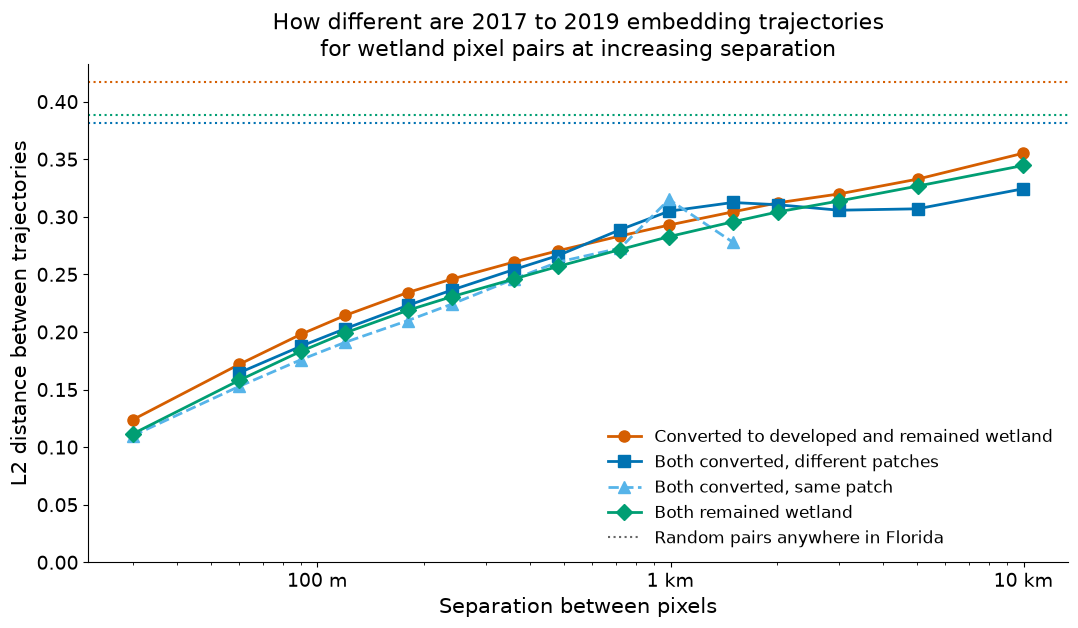

In [13]:
anchor_of = {"pos to neg": ("pos", [0]), "pos to pos, other patch": ("pos", [1]),
             "pos to pos, same patch": ("pos", [3]), "neg to neg, matched": ("neg_matched", [0])}
random_of = {"pos to neg": "pos to neg", "pos to pos, other patch": "pos to pos",
             "neg to neg, matched": "neg to neg, matched"}

fig, ax = plt.subplots(figsize=(11, 6.5))
for name, style in SERIES.items():
    a, cls = anchor_of[name]
    m = per_anchor_mean(*pair_stats[a], cls)
    n = (~np.isnan(m)).sum(axis=0)
    keep = n >= MIN_ANCHORS
    q50 = np.nanmedian(m[:, keep], axis=0)
    ax.plot(ring_m[keep], q50, color=style["color"], marker=style["marker"], ls=style["ls"],
            lw=2, ms=8, label=style["label"])
    if name in random_of:
        ax.axhline(np.median(random_ref[random_of[name]]), color=style["color"], ls=":", lw=1.5)

handles, labels = ax.get_legend_handles_labels()
handles.append(Line2D([], [], color="0.4", ls=":", lw=1.5))
labels.append("Random pairs anywhere in Florida")
ax.legend(handles, labels, frameon=False, loc="lower right")
log_x(ax)
ax.set_ylabel("L2 distance between trajectories")
ax.set_ylim(bottom=0)
ax.set_title("How different are 2017 to 2019 embedding trajectories\nfor wetland pixel pairs at increasing separation")
fig.tight_layout()
fig.savefig(OUT_DIR / "trajectory_distance_by_separation.png", dpi=200)
plt.show()

**Figure 2.** Left: median paired gap (pos to neg minus pos to pos, per positive anchor). Right: share of positive anchors whose remained wetland neighbors are farther away in trajectory space than their positive neighbors. 0.5 is no difference. Error bars are 95 percent CIs from a 1,000 draw bootstrap over blocks. Orange compares against every positive neighbor; blue only against positives in other patches.

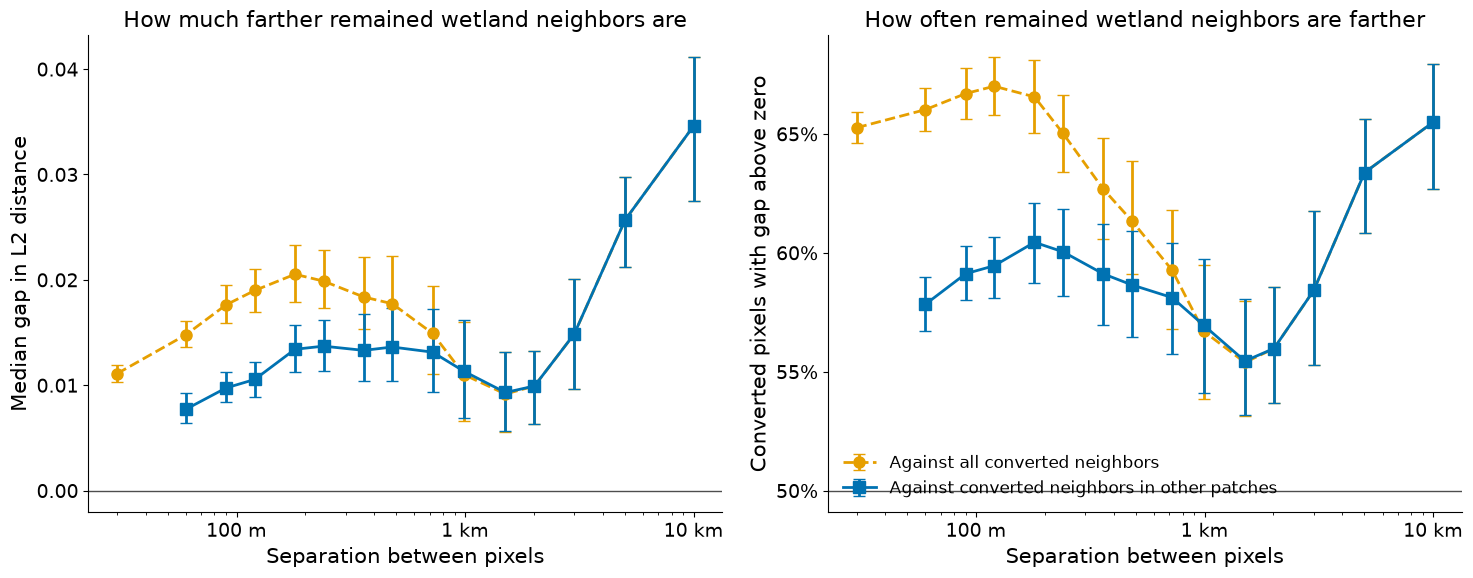

In [14]:
GAP_STYLE = {
    "against all positive neighbors": dict(color="#E69F00", marker="o", ls="--", label="Against all converted neighbors"),
    "against positives in other patches": dict(color="#0072B2", marker="s", ls="-", label="Against converted neighbors in other patches"),
}

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for comp, style in GAP_STYLE.items():
    t = gap_table[(gap_table.comparison == comp) & (gap_table.n_anchors >= MIN_ANCHORS)]
    for ax, col, lo, hi in [(axes[0], "median_gap", "median_gap_lo", "median_gap_hi"),
                            (axes[1], "frac_gap_above_0", "frac_lo", "frac_hi")]:
        ax.errorbar(t.ring_m, t[col], yerr=[t[col] - t[lo], t[hi] - t[col]], color=style["color"],
                    marker=style["marker"], ls=style["ls"], lw=2, ms=8, capsize=4, label=style["label"])

axes[0].axhline(0, color="0.3", lw=1)
axes[0].set_ylabel("Median gap in L2 distance")
axes[0].set_title("How much farther remained wetland neighbors are")
axes[1].axhline(0.5, color="0.3", lw=1)
axes[1].yaxis.set_major_locator(MultipleLocator(0.05))
axes[1].yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
axes[1].set_ylabel("Converted pixels with gap above zero")
axes[1].set_title("How often remained wetland neighbors are farther")
for ax in axes:
    log_x(ax)
axes[1].legend(frameon=False, loc="best")
fig.tight_layout()
fig.savefig(OUT_DIR / "paired_gap_by_separation.png", dpi=200)
plt.show()

**Figure 3.** Share of anchors that have at least one partner of each kind on the ring. The arrays only hold pixels that were wetland in 2019, so at large separation many ring cells fall on uplands, water or existing development and there is nothing to compare against. Thin coverage at a ring means the points above at that ring rest on a smaller, possibly unrepresentative set of anchors.

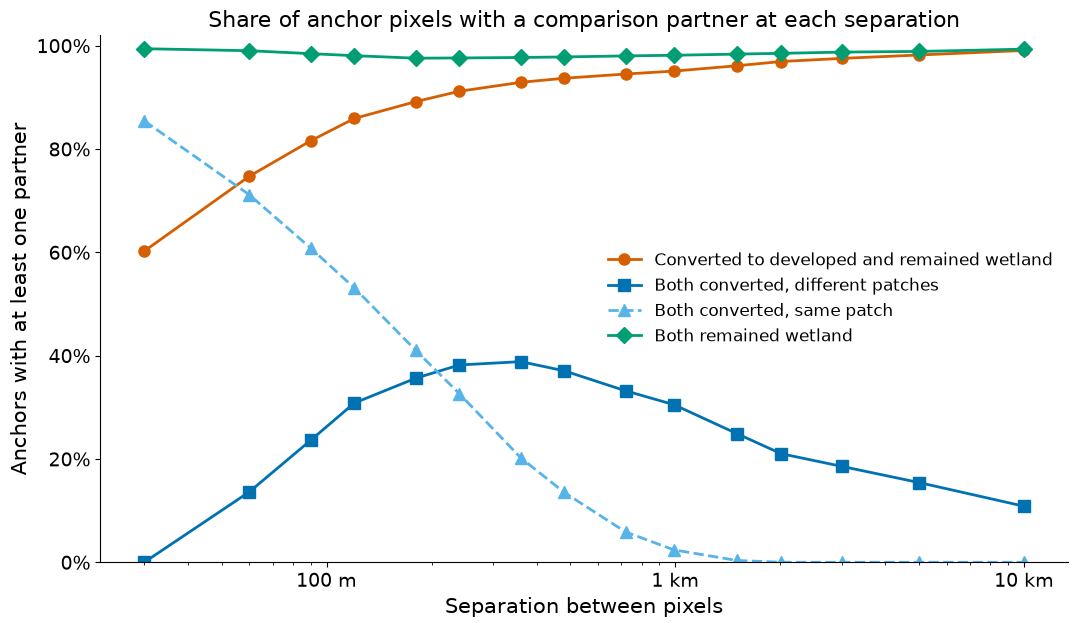

In [15]:
COVERAGE = {
    "pos to neg": ("pos", "with_neg"),
    "pos to pos, other patch": ("pos", None),
    "pos to pos, same patch": ("pos", "with_pos_same_patch"),
    "neg to neg, matched": ("neg_matched", "with_neg"),
}

fig, ax = plt.subplots(figsize=(11, 6.5))
for name, style in SERIES.items():
    a, col = COVERAGE[name]
    if col is None:
        share = (pair_stats[a][1][..., 1] > 0).mean(axis=0)
    else:
        c = coverage[coverage.anchors == a]
        share = (c[col] / c.n_anchors).to_numpy()
    ax.plot(ring_m, share, color=style["color"], marker=style["marker"], ls=style["ls"],
            lw=2, ms=8, label=style["label"])
log_x(ax)
ax.yaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax.set_ylim(0, 1.02)
ax.set_ylabel("Anchors with at least one partner")
ax.set_title("Share of anchor pixels with a comparison partner at each separation")
ax.legend(frameon=False, loc="best")
fig.tight_layout()
fig.savefig(OUT_DIR / "partner_coverage_by_separation.png", dpi=200)
plt.show()